In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # for creating rectangle patches
from scipy.stats import norm
import os
import micropip
await micropip.install('seaborn')
import seaborn as sns
import warnings # Ignore this line and the next - it's to get rid of some error messages that don't affect the running of the code
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [9]:
# create filepath to .csv file
filepath = os.path.join('data','AZE_1995_SLC', 'az_hh.csv')

# import data from .csv file
data_df = pd.read_csv(filepath)

# display first 5 rows of text
data_df.head()

,Household,members
0,100-11,2
1,100-12,3
2,100-13,4
3,100-14,3
4,100-15,2


In [38]:
#define an array variable containing the data in the column of interest in your .csv file

HHsize = data_df['members']

# Display the first five values for your variable

HHsize[0:5]

0    2
1    3
2    4
3    3
4    2
Name: members, dtype: int64

In [46]:
# Calculate mean and standard deviation, the number of data points, the number of unique data values, and the number of bins (including values for whihc nno data is recorded)
#use numpy for these calculations
data_mean = np.mean(HHsize)
data_std = np.std(HHsize)
data_count = HHsize.size
data_unique = data_df['members'].nunique()
num_bins = np.max(data_df['members'])-np.min(data_df['members'])+1

print(f'The actual Mean is {data_mean:.2f}')
print(f'The actual StDev is {data_std:.2f}')
print(f'The total number of household members is {data_count}')
print(f'The number of unique values in the "members" column is {data_unique}')
print(f'The number of bins is {num_bins}')

The actual Mean is 4.97
The actual StDev is 2.25
The total number of household members is 2016
The number of unique values in the "members" column is 16
The number of bins is 17


In [63]:
# Define range for x-axis using np.linspace (covering 3 standard deviations)
x = np.linspace(data_mean - 3*data_std, data_mean + 3*data_std, data_count)

# Theoretical normal distribution PDF
theoretical_pdf = norm.pdf(x, loc=data_mean, scale=data_std)

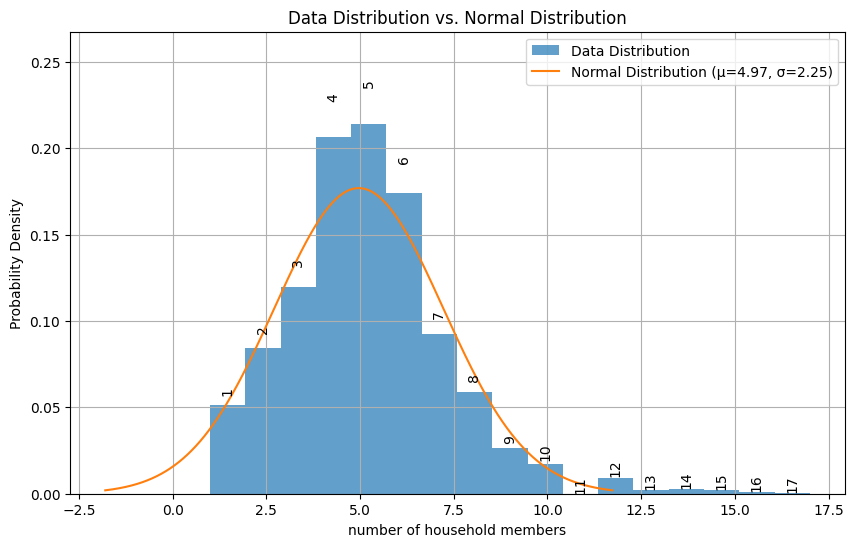

In [65]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram of the data
# plt.hist(HHsize, bins=num_bins, density=True, alpha=0.7, label="Data Distribution")
counts, bins, patches = plt.hist(HHsize, bins=num_bins, density=True, alpha=0.7, label="Data Distribution")

# Plot the theoretical normal distribution curve
plt.plot(x, theoretical_pdf, label="Normal Distribution (μ={:.2f}, σ={:.2f})".format(data_mean, data_std))

# Calculate bin centers
bin_centers = (bins[:-1] + bins[1:])/2

# Calculate maximum count for y-axis limit (including some buffer to avoid clipping labels)
max_count = max(counts) * 1.25  # Add some buffer to avoid clipping labels

plt.ylim(0, max_count)

# Round bin centers to integers
rounded_centers = np.rint(bin_centers).astype(int)  # Round and convert to integer

# Create custom labels (modify as needed)
labels = [str(c) for c in rounded_centers]  # Format bin centers as desired


# Set bar width (adjust for spacing if needed)
bar_width = bins[1] - bins[0]

# Create offsets for label positioning (adjust as needed)
x_offsets = [b - bar_width / 200 for b in bin_centers]  # Center labels within bars
y_offsets = [counts[i] * 1.1 for i in range(len(counts))]  # Position above bars

# Add labels using text annotations
for x, y, label in zip(x_offsets, y_offsets, labels):
  plt.text(x, y, label, ha='center', va='bottom',rotation=90)

# Add labels and title
plt.xlabel("number of household members")
plt.ylabel("Probability Density")
plt.title("Data Distribution vs. Normal Distribution")


# Add legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()